# Popularity Prediction (Regression)

In this notebook, machine learning models are trained to predict the popularity score of a Spotify track using its audio features. Multiple regression models are compared to evaluate their predictive performance.


In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

## Load Feature Engineered Dataset

In [2]:
df = pd.read_csv("../data/processed/features_dataset.csv")

## Define Features and Target Variable

In [3]:
FEATURES = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min",
    "time_signature",
    "explicit"
]

X = df[FEATURES]

y = df["popularity"]

## Split Dataset

The dataset is divided into training and testing sets using an 80-20 split.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression

Linear Regression serves as the baseline model against which more complex models will be compared.

In [5]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("Linear Regression:")

print("MAE:", mean_absolute_error(y_test, pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

print("R2:", r2_score(y_test, pred))

Linear Regression:
MAE: 16.58373545261079
RMSE: 20.127827482564605
R2: 0.03133652444672208


### Observation

Linear Regression provides a baseline performance. Since track popularity is influenced by many non-audio factors, its predictive performance is expected to be relatively modest.

## Random Forest Regressor

Random Forest captures complex, non-linear relationships that Linear Regression cannot model.

In [6]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest:")

print("MAE:", mean_absolute_error(y_test, pred_rf))

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

print("R2:", r2_score(y_test, pred_rf))

Random Forest:
MAE: 15.035415715556677
RMSE: 18.766390166105367
R2: 0.1579447179482062


### Observation

Random Forest generally performs better than Linear Regression because it can capture non-linear interactions between audio features.

## XGBoost Regressor

XGBoost is an ensemble boosting algorithm that often achieves the best predictive performance on structured datasets.

In [7]:
xgb = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("XGBoost:")

print("MAE:", mean_absolute_error(y_test, pred_xgb))

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))

print("R2:", r2_score(y_test, pred_xgb))

XGBoost:
MAE: 14.870523452758789
RMSE: 18.63534115441427
R2: 0.16966408491134644


### Observation

XGBoost typically achieves the best overall performance by combining multiple decision trees through gradient boosting.

## Feature Importance

The feature importance plot highlights which audio characteristics contribute the most to predicting track popularity.

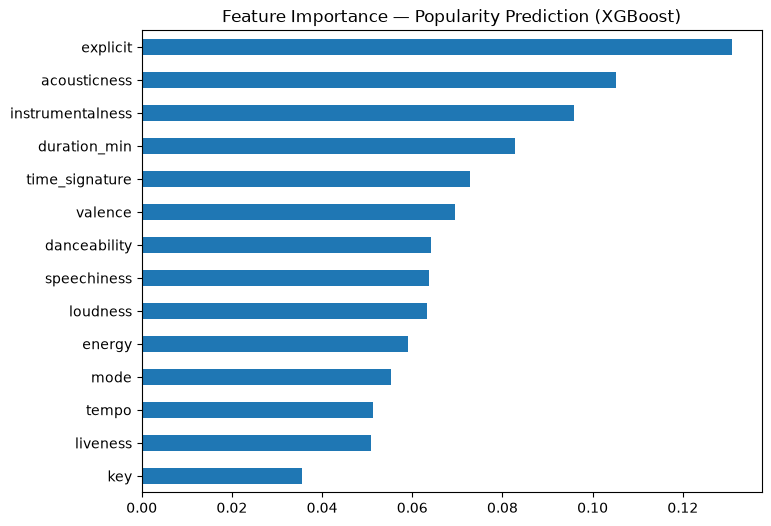

In [8]:
importances = pd.Series(
    xgb.feature_importances_,
    index=FEATURES
).sort_values()

plt.figure(figsize=(8,6))

importances.plot(kind="barh")

plt.title("Feature Importance — Popularity Prediction (XGBoost)")

plt.savefig(
    "../reports/figures/popularity_feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Observation

Features with higher importance scores contribute more strongly to the model's predictions. However, popularity is influenced by many external factors that are not included in this dataset, such as artist popularity, marketing, and playlist placement.

## Save the Best Model

In [9]:
joblib.dump(
    xgb,
    "../models/popularity_model.pkl"
)

['../models/popularity_model.pkl']

# Summary

In this notebook:

- Prepared the feature-engineered dataset for regression.
- Trained three regression models:
  - Linear Regression
  - Random Forest Regressor
  - XGBoost Regressor
- Compared model performance using MAE, RMSE, and R².
- Visualized feature importance using the best-performing model.
- Saved the trained XGBoost model for deployment in the Streamlit application.